<a href="https://colab.research.google.com/github/odaymoulahi-lab/projet-personnel/blob/main/projet_data_mining.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>



# **1.   import libraries || upload file Mall_Customers.csv**



In [ ]:

# Import des librairies
import pandas as pd # Charger le CSV, explorer les données (head(), info(), describe()), nettoyer (dropna(), fillna()), sélectionner des colonnes
import numpy as np # Calcul statistiques, numérique et scientifique (tableaux multidimensionnels, fonctions mathématiques)
import matplotlib.pyplot as plt # Visualisation graphique de données (histogrammes, courbes, nuages de points)
import seaborn as sns # Visualisation statistique avancée, plus esthétique que Matplotlib (histogrammes, boxplots, heatmaps, countplots)
from sklearn.preprocessing import StandardScaler # Normaliser les colonnes avant d’appliquer K‑Means
from sklearn.cluster import KMeans # Implémentation de l’algorithme K‑Means pour le clustering


from google.colab import files # Permettre le téléchargement de fichiers depuis l’ordinateur vers l’environnement Colab

# Uploader le fichier
uploaded = files.upload()  # Sélectionne "Mall_Customers.csv"

# Charger les données dans un DataFrame
df = pd.read_csv('Mall_Customers.csv')



Saving Mall_Customers.csv to Mall_Customers.csv



# **2. afficher les elements du fichier**



In [ ]:

# afficher les 5 1er lignes
print("Aperçu des 5 premières lignes :")
print(df.head())

print("\n")

# afficher les 5 dernier lignes
print("Aperçu des 5 dernières lignes :")
print(df.tail())



# **3. presenter le dataset**



In [ ]:

# Présenter le dataset (origine, taille, domaine, description)

# Dimensions du dataset
print("\nDimensions (lignes, colonnes) :", df.shape)

# Information sur les colonnes
print("\nInformations sur les colonnes :")
print()
print(df.info())

# Noms des colonnes
print("\nColonnes :", df.columns.tolist())

# Types de données
print("\n\nTypes :")
print()
print(df.dtypes)

# Résumé statistique des colonnes numériques
print("\n\nRésumé statistique :")
print()
print(df.describe())



# **4. Nettoyage**



In [ ]:

# Nettoyage :
print("\nNettoyage :")

# Nombre de valeurs manquantes par colonne
manquant = df.isnull().sum()
print("\nValeurs manquantes :")
print()
print(manquant) # == 0

# nombre des ligne identique
nb_id = df.duplicated().sum()
print("\nnombre des ligne identique =",nb_id) # == 0

if nb_id != 0 :
  print("\nLigne en double :")
  # detecter les ligne identique
  doublons = df[df.duplicated()]
  print()
  print(doublons)

print()
print("==> Aucune nettoyage n'est nécessaire") if nb_id == 0 and manquant.sum() == 0 else print("==> il y a des valeurs manquantes ou des doublons, nettoyage nécessaire!!")

# ==> aucune valeur manquante ou doublons
# ==> Aucune nettoyage n'est nécessaire




# **5. Application du cours || affichage graphique**




['CustomerID', 'Gender', 'Age', 'Annual Income (k$)', 'Spending Score (1-100)', 'Cluster']



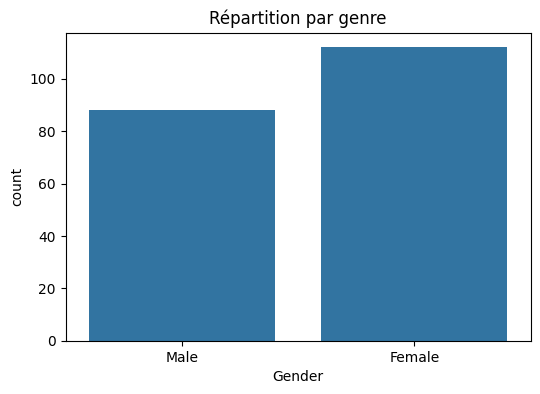

In [ ]:

# Vérifier les noms exacts des colonnes
print()
print(df.columns.tolist())
print()



# Distribution par genre (Gender)

# dimension de la figure
plt.figure(figsize=(6,4))

# les coordonnees pour l'histogramme qui affiche graphiquement le nombre de chaque genre (axe des x, les donnees fournis) : axe des y est automatiquement énoncé comme compteur
sns.countplot(x='Gender', data=df)

# titre de figure
plt.title('Répartition par genre')

# commende pour afficher le resultats
plt.show()


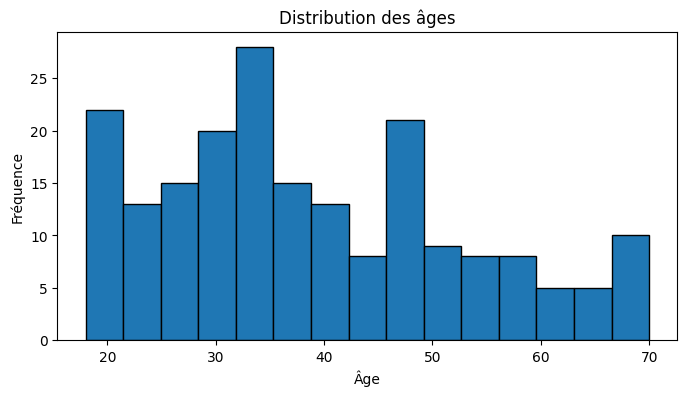

In [ ]:

# Histogramme de l'âge (Age)

# dimension de la figure
plt.figure(figsize=(8,4))

# les coordonners du histogramme (l'axe des x fournis par les donner de la colonne age du dataframe, bins : Divise les données en 15 intervalles égaux, coloration du bordure)
plt.hist(df['Age'], bins=15, edgecolor='black')

# nommee l'axe des x par Âge
plt.xlabel('Âge')

# nommee l'axe des y par Fréquence
plt.ylabel('Fréquence')

# titre de figure
plt.title('Distribution des âges')

# commende pour afficher le resultats
plt.show()


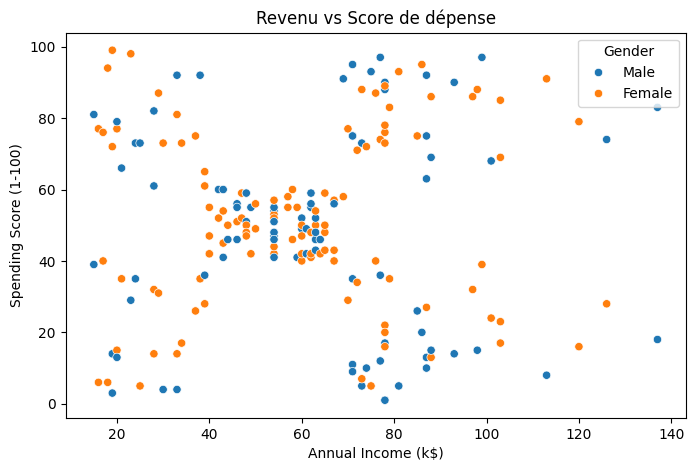

In [ ]:

# Nuage de points Revenu annuel vs Score de dépense

# dimension de la figure
plt.figure(figsize=(8,5))

# les coordonners du scatterplot (axe des x, axe des y, les donnees fournis, repartition couleur par le genre)
sns.scatterplot(x='Annual Income (k$)', y='Spending Score (1-100)', data=df, hue='Gender')

# titre de figure
plt.title('Revenu vs Score de dépense')

# commende pour afficher le resultats
plt.show()




# **6.   Tache Clustering**


In [ ]:

# avant le clustering

# On sélectionne 2 colonnes numériques car L'algorithme K-Means ne peut pas traiter de texte
X = df[['Annual Income (k$)', 'Spending Score (1-100)']]

# verifier les variable retenue
print("Variables retenues :", X.columns.tolist())
print()

# afficher les 5 1er lignes du X
print(X.head())

# K-Means utilise la distance euclidienne → il faut standardiser
scaler = StandardScaler()

# Calculer les paramètres (moyenne/écart-type) et transformer les données (X) en une seule étape
# <<fit>> calcule la moyenne et l'écart-type de chaque colonne, et <<transform>> applique la formule pour transformer les valeurs de X
X_scaled = scaler.fit_transform(X)

print("\nMoyenne des colonnes standardisées :")
print()
print(X_scaled)


Variables retenues : ['Annual Income (k$)', 'Spending Score (1-100)']

   Annual Income (k$)  Spending Score (1-100)
0                  15                      39
1                  15                      81
2                  16                       6
3                  16                      77
4                  17                      40

Moyenne des colonnes standardisées :

[[-1.73899919 -0.43480148]
 [-1.73899919  1.19570407]
 [-1.70082976 -1.71591298]
 [-1.70082976  1.04041783]
 [-1.66266033 -0.39597992]
 [-1.66266033  1.00159627]
 [-1.62449091 -1.71591298]
 [-1.62449091  1.70038436]
 [-1.58632148 -1.83237767]
 [-1.58632148  0.84631002]
 [-1.58632148 -1.4053405 ]
 [-1.58632148  1.89449216]
 [-1.54815205 -1.36651894]
 [-1.54815205  1.04041783]
 [-1.54815205 -1.44416206]
 [-1.54815205  1.11806095]
 [-1.50998262 -0.59008772]
 [-1.50998262  0.61338066]
 [-1.43364376 -0.82301709]
 [-1.43364376  1.8556706 ]
 [-1.39547433 -0.59008772]
 [-1.39547433  0.88513158]
 [-1.3573049  -1.754



#    **Methode de Coude**

---


**Étapes clés de la méthode du coude :**

* **Exécution de K-Means :** Faire tourner l'algorithme pour une gamme de valeurs de
 (par exemple, 1 à 10 ou 1 à 20).
* **Calcul du WCSS (Within-Cluster Sum of Squares) :** Pour chaque K, calculer la somme des distances au carré entre chaque point et le centre de son cluster (aussi appelé inertie).
* **Tracé du graphique :** Représenter le WCSS en fonction du nombre de clusters (
).
* **Identification du "coude" :** Chercher le point où la courbe décroît fortement puis se stabilise (le point d'inflexion).


In [ ]:

# Convertir en DataFrame pour lisibilité
X_scaled_df = pd.DataFrame(X_scaled, columns=X.columns)
print("DataFrame après standardisation :")
print(X_scaled_df.head())


#  Crée une liste vide qui servira à stocker l'inertie (la somme des distances au carré entre chaque point et son centre de cluster) pour chaque valeur de K
inertias = []

# Définit une plage de nombres de 1 à 10. On va tester le modèle avec 1 cluster, puis 2, puis 3, jusqu'à 10
K_range = range(1, 51)

# On teste chaque nombre de clusters (de 1 à 10) un par un
for k in K_range:

  # On initialise l'algorithme pour k clusters avec un résultat reproductible
  kmeans = KMeans(n_clusters=k, random_state=42)

  # On lance l'entraînement (le calcul des distances et des groupes)
  kmeans.fit(X_scaled)

  # On mémorise le score (l'inertie) pour savoir si le découpage est efficace
  inertias.append(kmeans.inertia_)


print(inertias)


DataFrame après standardisation :
   Annual Income (k$)  Spending Score (1-100)
0           -1.738999               -0.434801
1           -1.738999                1.195704
2           -1.700830               -1.715913
3           -1.700830                1.040418
4           -1.662660               -0.395980
[399.99999999999994, 273.66888662642003, 157.70400815035939, 109.22822707921345, 65.56840815571681, 60.132874871934206, 49.668244837367965, 37.31912287833882, 32.495081199100916, 30.05932269404222, 26.7612017663612, 26.232893769786845, 23.1935534219784, 21.195257238649532, 18.17910484933539, 16.082488779041746, 15.242557975456648, 14.618057440193681, 13.88843792308299, 12.694432487093298, 11.877753775460315, 10.644587702902395, 10.10456971411234, 9.644769716040306, 9.306358985817168, 8.813069711229417, 8.314660102369425, 8.066336088100488, 7.8032348261160775, 7.593891964536556, 7.341688511981803, 7.152961678422121, 6.668810461138853, 6.524324815412801, 6.257857512034536, 6.03897605



> **courbe de coude**



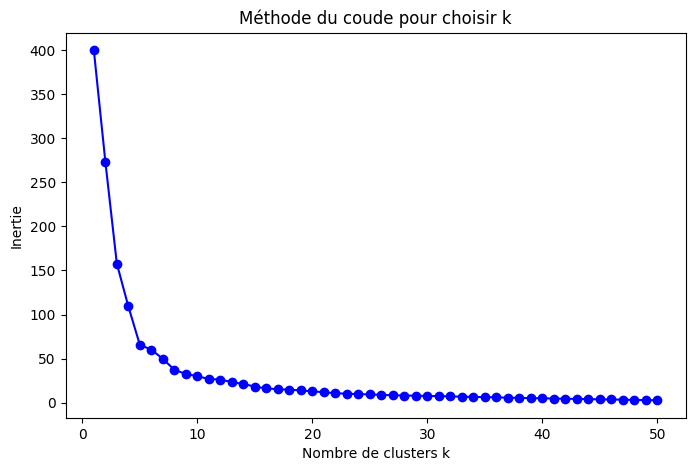

In [ ]:

# Tracé de la courbe du coude
plt.figure(figsize=(8,5))
plt.plot(K_range, inertias, 'bo-')
plt.xlabel('Nombre de clusters k')
plt.ylabel('Inertie')
plt.title('Méthode du coude pour choisir k')
# plt.grid(True)
plt.show()



Labels des clusters ajoutés au DataFrame :

   CustomerID  Gender  Age  Annual Income (k$)  Spending Score (1-100)  \
0           1    Male   19                  15                      39   
1           2    Male   21                  15                      81   
2           3  Female   20                  16                       6   
3           4  Female   23                  16                      77   
4           5  Female   31                  17                      40   

   Cluster  
0        4  
1        2  
2        4  
3        2  
4        4  

Profil moyen par cluster :

         Annual Income (k$)  Spending Score (1-100)  Taille
Cluster                                                    
0                 55.296296               49.518519      81
1                 86.538462               82.128205      39
2                 25.727273               79.363636      22
3                 88.200000               17.114286      35
4                 26.304348               2

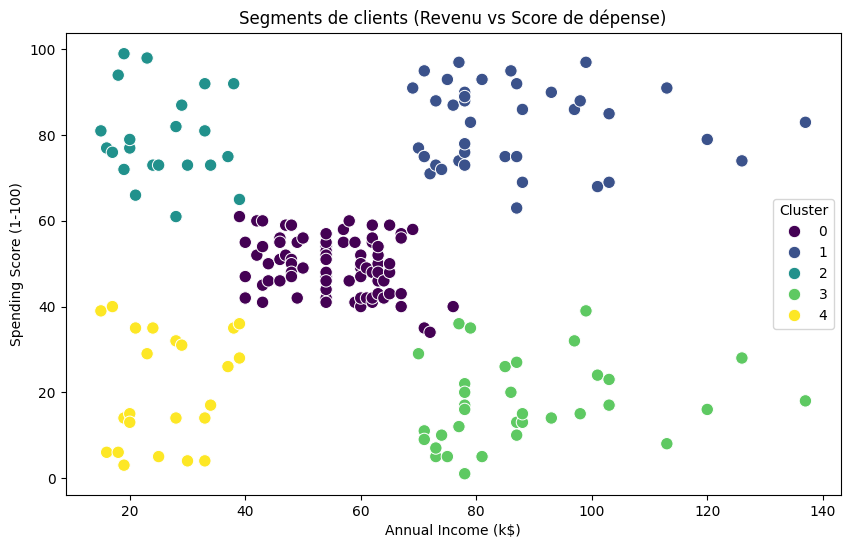

In [ ]:
# Choisir k=5 (selon le coude)==> la pt x=5 represente la point d'inflexion de la courbe
kmeans = KMeans(n_clusters=5, random_state=42)

# On calcule les groupes et on enregistre le numéro du groupe pour chaque client
df['Cluster'] = kmeans.fit_predict(X_scaled)

# On affiche les premières lignes pour voir la nouvelle colonne 'Cluster'
print("\nLabels des clusters ajoutés au DataFrame :")
print()
print(df.head())

# On calcule la moyenne des données (Revenu, Score) pour chaque groupe
cluster_profile = df.groupby('Cluster')[['Annual Income (k$)', 'Spending Score (1-100)']].mean()

# On ajoute une colonne pour savoir combien il y a de clients dans chaque groupe
cluster_profile['Taille'] = df['Cluster'].value_counts().sort_index()

# On affiche le tableau résumé des groupes
print("\nProfil moyen par cluster :")
print()
print(cluster_profile)

# On prépare la zone du graphique
plt.figure(figsize=(10,6))

# On dessine les points : Revenu en bas, Score à gauche, et une couleur par groupe
# (axe des x, axe des y, teinte des points en fonction du numéro de groupe(selon la colonne 'cluster'), la taille des points)
sns.scatterplot(x='Annual Income (k$)', y='Spending Score (1-100)', hue='Cluster', data=df, palette='viridis', s=80)

# On ajoute le titre et la légende au graphique
plt.title('Segments de clients (Revenu vs Score de dépense)')
plt.legend(title='Cluster')

# On affiche le résultat final à l'écran
plt.show()


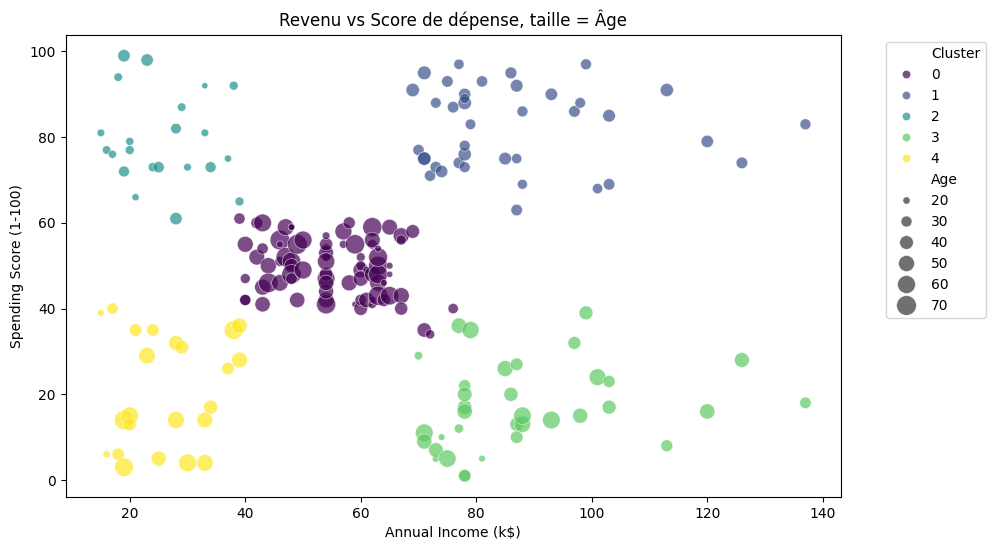

In [ ]:
plt.figure(figsize=(10,6))
sns.scatterplot(x='Annual Income (k$)', y='Spending Score (1-100)', hue='Cluster', size='Age', data=df, palette='viridis', sizes=(20, 200), alpha=0.7)
plt.title('Revenu vs Score de dépense, taille = Âge')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()

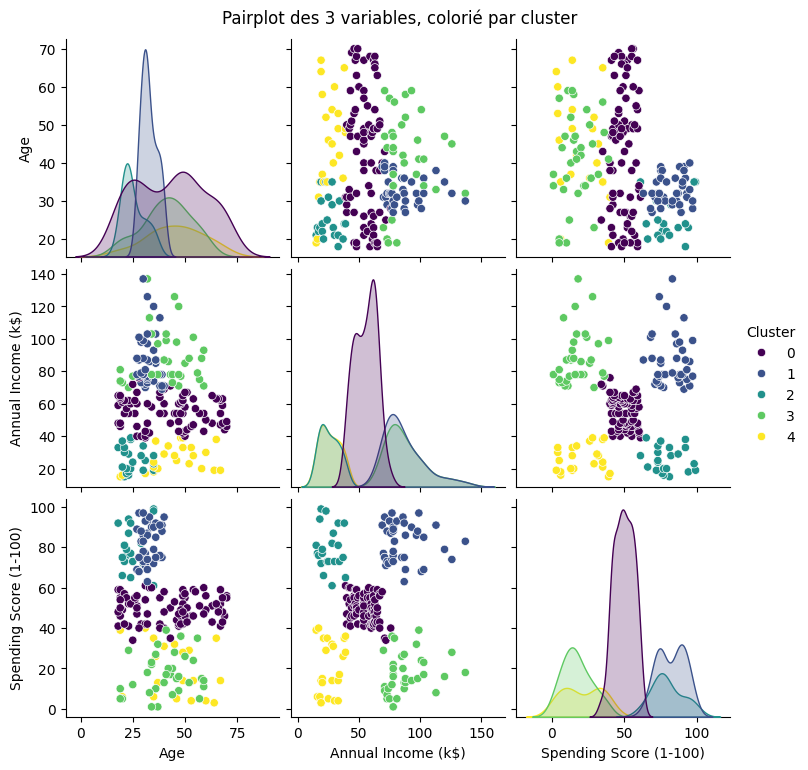

In [ ]:
# Pairplot complet (3 variables x 3)
sns.pairplot(df, vars=['Age', 'Annual Income (k$)', 'Spending Score (1-100)'],
             hue='Cluster', palette='viridis', diag_kind='kde')
plt.suptitle('Pairplot des 3 variables, colorié par cluster', y=1.02)
plt.show()

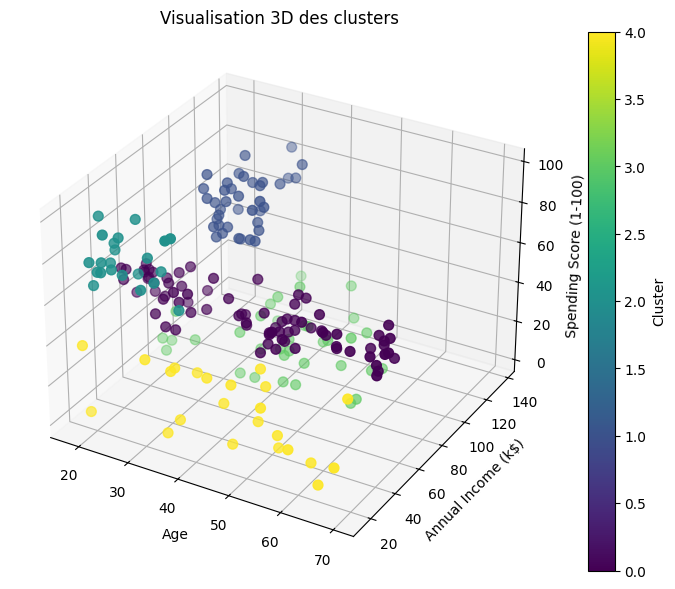

In [ ]:
from mpl_toolkits.mplot3d import Axes3D

fig = plt.figure(figsize=(10,7))
ax = fig.add_subplot(111, projection='3d')
scatter = ax.scatter(df['Age'], df['Annual Income (k$)'], df['Spending Score (1-100)'],
                     c=df['Cluster'], cmap='viridis', s=50)
ax.set_xlabel('Age')
ax.set_ylabel('Annual Income (k$)')
ax.set_zlabel('Spending Score (1-100)')
plt.title('Visualisation 3D des clusters')
plt.colorbar(scatter, label='Cluster')
plt.show()